# Pengenalan Pola Assignment#1: 1D Signal Classification<br>

Anggota Kelompok:<br>
Kenji Ratanaputra (24/534421/PA/22664) <br>
Thufail Bahir Al Bariq (24/537843/PA/22801) <br>
Marco Christian (24/539714/PA/22915) <br>

In [2]:
import os
import pandas as pd
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.svm import SVC
from sklearn.metrics import(
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import definitions as d

### Dataset Overview

In [3]:
data = d.get_data_files()
data

,full_path,parent_path,file_name,actor_num,modelity,vocal_channel,emotion,emotional_intensity,statement,repetition,actor_gender
0,RAVDESS\Actor_01\03-01-01-01-01-01-01.wav,RAVDESS\Actor_01,03-01-01-01-01-01-01.wav,01,audio-only,speech,neutral,normal,Kids are talking by the door,1st repetation,male
1,RAVDESS\Actor_01\03-01-01-01-01-02-01.wav,RAVDESS\Actor_01,03-01-01-01-01-02-01.wav,01,audio-only,speech,neutral,normal,Kids are talking by the door,2nd repetation,male
2,RAVDESS\Actor_01\03-01-01-01-02-01-01.wav,RAVDESS\Actor_01,03-01-01-01-02-01-01.wav,01,audio-only,speech,neutral,normal,Dogs are sitting by the door,1st repetation,male
3,RAVDESS\Actor_01\03-01-01-01-02-02-01.wav,RAVDESS\Actor_01,03-01-01-01-02-02-01.wav,01,audio-only,speech,neutral,normal,Dogs are sitting by the door,2nd repetation,male
4,RAVDESS\Actor_01\03-01-02-01-01-01-01.wav,RAVDESS\Actor_01,03-01-02-01-01-01-01.wav,01,audio-only,speech,calm,normal,Kids are talking by the door,1st repetation,male
...,...,...,...,...,...,...,...,...,...,...,...
1435,RAVDESS\Actor_24\03-01-08-01-02-02-24.wav,RAVDESS\Actor_24,03-01-08-01-02-02-24.wav,24,audio-only,speech,surprised,normal,Dogs are sitting by the door,2nd repetation,female
1436,RAVDESS\Actor_24\03-01-08-02-01-01-24.wav,RAVDESS\Actor_24,03-01-08-02-01-01-24.wav,24,audio-only,speech,surprised,strong,Kids are talking by the door,1st repetation,female
1437,RAVDESS\Actor_24\03-01-08-02-01-02-24.wav,RAVDESS\Actor_24,03-01-08-02-01-02-24.wav,24,audio-only,speech,surprised,strong,Kids are talking by the door,2nd repetation,female
1438,RAVDESS\Actor_24\03-01-08-02-02-01-24.wav,RAVDESS\Actor_24,03-01-08-02-02-01-24.wav,24,audio-only,speech,surprised,strong,Dogs are sitting by the door,1st repetation,female


In [4]:
X = data.drop(columns=["actor_gender"])
y = data["actor_gender"]
groups = data["actor_num"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

train = data.iloc[train_idx].copy()
test = data.iloc[test_idx].copy()

In [5]:
print("Train actors:")
print(sorted(train["actor_num"].unique()))

print("\nTest actors:")
print(sorted(test["actor_num"].unique()))

Train actors:
['02', '03', '04', '05', '06', '07', '08', '10', '11', '13', '14', '15', '16', '18', '20', '21', '22', '23', '24']

Test actors:
['01', '09', '12', '17', '19']


In [6]:
overlap = set(train["actor_num"]) & set(test["actor_num"])

print("Speaker overlap:", overlap)

Speaker overlap: set()


In [7]:
print("Clips per gender (train):")
print(train["actor_gender"].value_counts())

print("\nClips per gender (test):")
print(test["actor_gender"].value_counts())

Clips per gender (train):
actor_gender
female    660
male      480
Name: count, dtype: int64

Clips per gender (test):
actor_gender
male      240
female     60
Name: count, dtype: int64


In [8]:
print("Unique speaker per gender (train):")
print(train.dropna(subset=['actor_gender']).groupby('actor_gender')['actor_num'].nunique())
print("\nUnique speaker per gender (test):")
print(test.dropna(subset=['actor_gender']).groupby('actor_gender')['actor_num'].nunique())

Unique speaker per gender (train):
actor_gender
female    11
male       8
Name: actor_num, dtype: int64

Unique speaker per gender (test):
actor_gender
female    1
male      4
Name: actor_num, dtype: int64


In [9]:
train['actor_gender'].isnull().sum()

np.int64(0)

In [10]:
test['actor_gender'].isnull().sum()

np.int64(0)

### Preprocessing

Take only path and gender for the classification

In [11]:
df_train = train[['full_path', 'actor_gender']]
df_test = test[['full_path', 'actor_gender']]

Check if file actually exists in folder

In [12]:
df_train['valid_file'] = df_train['full_path'].apply(
    lambda x: os.path.exists(x)
)

df_test['valid_file'] = df_test['full_path'].apply(
    lambda x: os.path.exists(x)
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16276\1772146661.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['valid_file'] = df_train['full_path'].apply(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16276\1772146661.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['valid_file'] = df_test['full_path'].apply(


In [13]:
print("Train files not found:", (~df_train['valid_file']).sum())
print("Test files not found:", (~df_test['valid_file']).sum())

Train files not found: 0
Test files not found: 0


In [14]:
df_train = df_train.drop(columns=['valid_file'])
df_test = df_test.drop(columns=['valid_file'])

Labels the target value (gender) to numeric value

In [15]:
label_mapping = {
    "male": 0,
    "female": 1
}

df_train['label'] = df_train['actor_gender'].map(label_mapping)
df_test['label'] = df_test['actor_gender'].map(label_mapping)

In [16]:
pd.set_option("display.max_colwidth", None)
df_train

,full_path,actor_gender,label
60,RAVDESS\Actor_02\03-01-01-01-01-01-02.wav,female,1
61,RAVDESS\Actor_02\03-01-01-01-01-02-02.wav,female,1
62,RAVDESS\Actor_02\03-01-01-01-02-01-02.wav,female,1
63,RAVDESS\Actor_02\03-01-01-01-02-02-02.wav,female,1
64,RAVDESS\Actor_02\03-01-02-01-01-01-02.wav,female,1
...,...,...,...
1435,RAVDESS\Actor_24\03-01-08-01-02-02-24.wav,female,1
1436,RAVDESS\Actor_24\03-01-08-02-01-01-24.wav,female,1
1437,RAVDESS\Actor_24\03-01-08-02-01-02-24.wav,female,1
1438,RAVDESS\Actor_24\03-01-08-02-02-01-24.wav,female,1


In [17]:
df_test

,full_path,actor_gender,label
0,RAVDESS\Actor_01\03-01-01-01-01-01-01.wav,male,0
1,RAVDESS\Actor_01\03-01-01-01-01-02-01.wav,male,0
2,RAVDESS\Actor_01\03-01-01-01-02-01-01.wav,male,0
3,RAVDESS\Actor_01\03-01-01-01-02-02-01.wav,male,0
4,RAVDESS\Actor_01\03-01-02-01-01-01-01.wav,male,0
...,...,...,...
1135,RAVDESS\Actor_19\03-01-08-01-02-02-19.wav,male,0
1136,RAVDESS\Actor_19\03-01-08-02-01-01-19.wav,male,0
1137,RAVDESS\Actor_19\03-01-08-02-01-02-19.wav,male,0
1138,RAVDESS\Actor_19\03-01-08-02-02-01-19.wav,male,0


Test to load an audio file

In [18]:
audio_path = df_train.iloc[0]["full_path"]

audio, sr = librosa.load(
    audio_path,
    sr=16000,
    mono = True
)

In [19]:
print("Sampling rate    :", sr)
print("Number of sample :", len(audio))
print("Duration         :", len(audio) / sr, "detik")

Sampling rate    : 16000
Number of sample : 58192
Duration         : 3.637 detik


<function matplotlib.pyplot.show(close=None, block=None)>

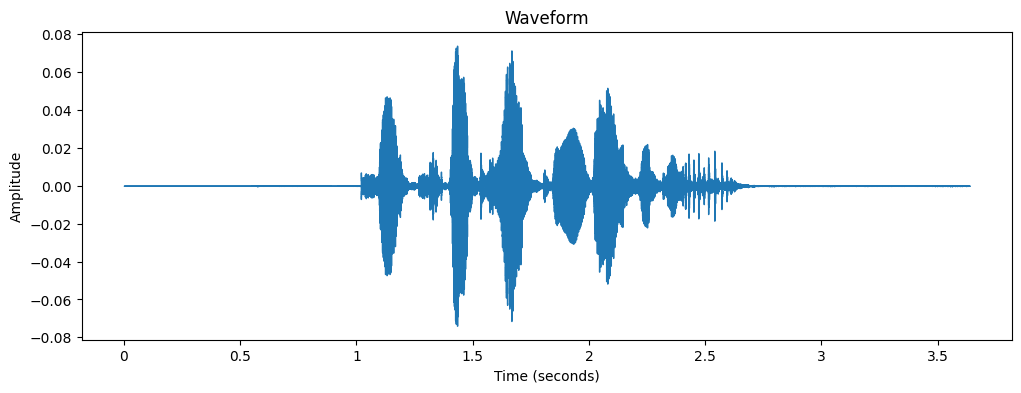

In [20]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(
    audio,
    sr=sr
)

plt.title("Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show


### Feature Extraction

Extract audio features using **MFCC, Zero-Crossing Rate (ZCR), Spectral Centroid, Spectral Bandwidth, RMS Energy, and Fundamental Frequency (F0/pitch)**. For each feature, the mean and standard deviation are calculated to obtain a fixed-length representation. All resulting features are concatenated into a single feature vector. In total, each audio sample is represented by **36 features**.

In [21]:
def extract_features(audio_path):
    try:
        #Load audio
        audio, sr = librosa.load(
            audio_path,
            sr=16000,
            mono=True
        )

        #Normalize
        audio = librosa.util.normalize(audio)

        #MFCC
        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sr,
            n_mfcc=13
        )

        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)

        #ZCR
        zcr = librosa.feature.zero_crossing_rate(audio)

        zcr_mean = np.mean(zcr)
        zcr_std = np.std(zcr)

        #Spectral Centroid
        spectral_centroid = librosa.feature.spectral_centroid(
            y=audio,
            sr=sr
        )

        spectral_centroid_mean = np.mean(spectral_centroid)
        spectral_centroid_std = np.std(spectral_centroid)

        #Spectral Bandwidth
        spectral_bandwidth = librosa.feature.spectral_bandwidth(
            y=audio,
            sr=sr
        )

        spectral_bandwidth_mean = np.mean(spectral_bandwidth)
        spectral_bandwidth_std = np.std(spectral_bandwidth)

        #RMS
        rms = librosa.feature.rms(y=audio)

        rms_mean = np.mean(rms)
        rms_std = np.std(rms)

        #F0/Pitch
        f0, voiced_flag, voiced_prob = librosa.pyin(
            audio,
            fmin=50,
            fmax=400,
            sr=sr
        )

        if np.any(~np.isnan(f0)):
            f0_mean = np.nanmean(f0)
            f0_std = np.nanstd(f0)
        else:
            f0_mean = 0.0
            f0_std = 0.0

        #Combine all features
        features = np.concatenate([
            mfcc_mean,
            mfcc_std,
            [zcr_mean, zcr_std],
            [spectral_centroid_mean, spectral_centroid_std],
            [spectral_bandwidth_mean, spectral_bandwidth_std],
            [rms_mean, rms_std],
            [f0_mean, f0_std]
        ])

        return features

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None


Test to extract features from an audio file

In [22]:
features = extract_features(audio_path)
print(features)
print("Number of features:", len(features))

[-3.79997803e+02  4.72171478e+01 -9.61525059e+00  8.32489586e+00
 -9.73989105e+00 -1.62161064e+00 -1.25939255e+01 -4.47760677e+00
 -3.67647958e+00 -2.46450806e+00 -5.58210802e+00 -2.11296320e+00
 -3.49898291e+00  1.96429337e+02  5.40377121e+01  3.59635048e+01
  2.01103306e+01  2.21567745e+01  1.29423847e+01  1.96311569e+01
  1.16947660e+01  1.11087084e+01  7.79734993e+00  1.01708965e+01
  8.37100506e+00  7.44042301e+00  2.74748150e-01  2.38325046e-01
  2.00910365e+03  1.25337805e+03  1.57054044e+03  7.98554662e+02
  5.08403033e-02  7.07337111e-02  2.19063198e+02  9.77220058e+01]
Number of features: 36


Apply feature extraction to all audio file

In [23]:
#Sample data for pipeline testing
#df_train_sample = df_train.head(500).copy()
#df_test_sample = df_test.head(200).copy()

In [24]:
X_train_list = []
y_train_list = []

for _, row in df_train.iterrows():
    features = extract_features(row['full_path'])

    if features is not None:
        X_train_list.append(features)
        y_train_list.append(row['label'])

In [25]:
X_train = np.array(X_train_list)
y_train = np.array(y_train_list)

print(X_train.shape)
print(y_train.shape)

(1140, 36)
(1140,)


In [26]:
X_test_list = []
y_test_list = []

for _, row in df_test.iterrows():
    features = extract_features(row['full_path'])

    if features is not None:
        X_test_list.append(features)
        y_test_list.append(row['label'])

In [27]:
X_test = np.array(X_test_list)
y_test = np.array(y_test_list)

print(X_test.shape)
print(y_test.shape)

(300, 36)
(300,)


### Modeling and Classification

Apply standardization scaling on features

In [28]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

SVM

In [29]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=41)

grid_search = GridSearchCV(
    SVC(class_weight='balanced', random_state=41),
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best params        :", grid_search.best_params_)
print("Best CV bal. acc.   :", grid_search.best_score_)

svm = grid_search.best_estimator_


Best params        : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV bal. acc.   : 0.9953598484848485


In [30]:
y_pred = svm.predict(X_test_scaled)

In [31]:
print(classification_report(y_test, y_pred, target_names=["Male", "Female"]))

              precision    recall  f1-score   support

        Male       0.99      0.92      0.95       240
      Female       0.75      0.95      0.84        60

    accuracy                           0.93       300
   macro avg       0.87      0.94      0.90       300
weighted avg       0.94      0.93      0.93       300



In [32]:
from sklearn.metrics import balanced_accuracy_score

y_train_pred = svm.predict(X_train_scaled)

print("=== TRAIN ===")
print(classification_report(y_train, y_train_pred, target_names=["Male", "Female"]))
print("Balanced accuracy (train):", balanced_accuracy_score(y_train, y_train_pred))

print("\n=== TEST ===")
print("Balanced accuracy (test) :", balanced_accuracy_score(y_test, y_pred))


=== TRAIN ===
              precision    recall  f1-score   support

        Male       1.00      1.00      1.00       480
      Female       1.00      1.00      1.00       660

    accuracy                           1.00      1140
   macro avg       1.00      1.00      1.00      1140
weighted avg       1.00      1.00      1.00      1140

Balanced accuracy (train): 0.9971590909090909

=== TEST ===
Balanced accuracy (test) : 0.9354166666666666


In [33]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[221  19]
 [  3  57]]


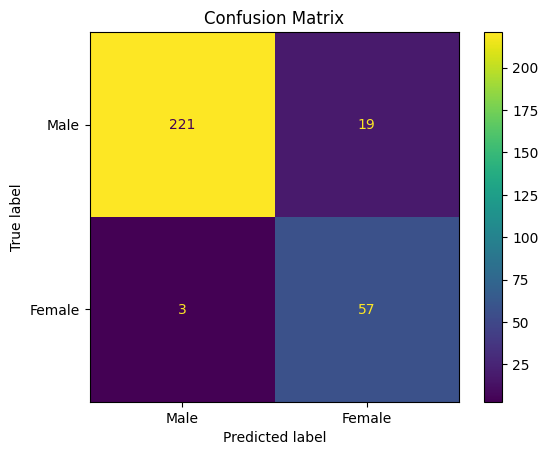

In [34]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Male", "Female"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()

#### Testing ke dataset Common Voice Speech Indonesia

In [35]:
test_cv = pd.read_csv(
    './cv-corpus-26.0-2026-06-12/id/test.tsv',
    sep='\t'
    )

In [37]:
test_cv = test_cv[['path', 'gender']]

In [39]:
before = len(test_cv)
test_cv = test_cv.dropna()
after = len(test_cv)

print(f"Rows dropped: {before - after}")

Rows dropped: 1559


In [41]:
CLIPS_PATH = "./cv-corpus-26.0-2026-06-12/id/clips"

test_cv['audio_path'] = test_cv['path'].apply(
    lambda x: f"{CLIPS_PATH}/{x}"
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16276\1228032924.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_cv['audio_path'] = test_cv['path'].apply(


In [52]:
test_cv['valid_file'] = test_cv['audio_path'].apply(
    lambda x: os.path.exists(x)
)
print("Test files not found:", (~test_cv['valid_file']).sum())

Test files not found: 0


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16276\1552667405.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_cv['valid_file'] = test_cv['audio_path'].apply(


In [54]:
test_cv = test_cv.drop(columns=['valid_file'])

In [42]:
label_mapping = {
    "male_masculine": 0,
    "female_feminine": 1
}

test_cv['label'] = test_cv['gender'].map(label_mapping)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16276\2843357555.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_cv['label'] = test_cv['gender'].map(label_mapping)


In [55]:
test_cv

,path,gender,audio_path,label
0,common_voice_id_23817543.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_23817543.mp3,0
1,common_voice_id_23769335.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_23769335.mp3,0
2,common_voice_id_23817591.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_23817591.mp3,0
3,common_voice_id_23769283.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_23769283.mp3,0
4,common_voice_id_20362404.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_20362404.mp3,0
...,...,...,...,...
3679,common_voice_id_23933132.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_23933132.mp3,0
3682,common_voice_id_27389019.mp3,female_feminine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_27389019.mp3,1
3689,common_voice_id_39610466.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_39610466.mp3,0
3696,common_voice_id_23033570.mp3,male_masculine,./cv-corpus-26.0-2026-06-12/id/clips/common_voice_id_23033570.mp3,0


In [44]:
X_test_cv_list = []
y_test_cv_list = []

for _, row in test_cv.iterrows():
    features_cv = extract_features(row['audio_path'])

    if features_cv is not None:
        X_test_cv_list.append(features_cv)
        y_test_cv_list.append(row['label'])

In [56]:
X_test_cv = np.array(X_test_cv_list)
y_test_cv = np.array(y_test_cv_list)

print(X_test_cv.shape)
print(y_test_cv.shape)

(2141, 36)
(2141,)


In [57]:
X_test_cv_scaled = scaler.transform(X_test_cv)

In [58]:
y_pred_cv = svm.predict(X_test_cv_scaled)

In [59]:
print(classification_report(y_test_cv, y_pred_cv, target_names=["Male", "Female"]))

              precision    recall  f1-score   support

        Male       0.92      0.37      0.53      1684
      Female       0.27      0.88      0.42       457

    accuracy                           0.48      2141
   macro avg       0.60      0.62      0.47      2141
weighted avg       0.78      0.48      0.50      2141



In [63]:
cm_cv = confusion_matrix(y_test_cv, y_pred_cv)
print(cm_cv)

[[ 621 1063]
 [  56  401]]


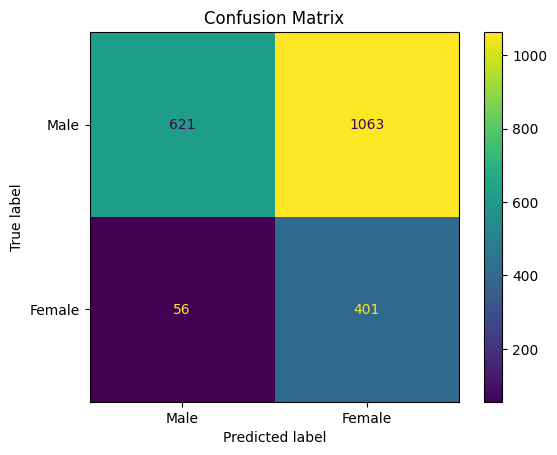

In [64]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_cv,
    display_labels=["Male", "Female"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()